# Data blocking

In this notebook I inspect the output of one strain-stress simulation with MACE potential, inspect the output, demonstrate data-blocking, and fix the analysis pipeline.

In [1]:
!which python

/home/gabrielecolombo/Thesis/PROJECT/.venv/bin/python


In [2]:
import numpy as np
import pandas as pd

from lammps_logfile import read_log

import matplotlib.pyplot as plt

from scipy.signal import periodogram, correlate

from ase.io import write

## Load data

Load and check everything is as expected.

In [3]:
thermo = read_log("STRAINSTRESS/strainstress.log")
thermo = thermo[thermo['c_press_compute[1]'].notnull()]
thermo = thermo[thermo['v_exx'].notnull()]
thermo = thermo[thermo['v_eyy'].notnull()]


In [4]:
thermo.keys()

Index(['Step', 'Temp', 'E_pair', 'E_mol', 'TotEng', 'Press', 'run_num', 'Lx',
       'Ly', 'Lz', 'Xy', 'Xz', 'Yz', 'v_exx', 'v_eyy', 'v_ezz', 'v_gxy',
       'v_gxz', 'v_gyz', 'c_press_compute[1]', 'c_press_compute[2]',
       'c_press_compute[3]', 'c_press_compute[4]', 'c_press_compute[5]',
       'c_press_compute[6]', 'PotEng', 'KinEng'],
      dtype='object')

## Raw strain-stress data

In [5]:
BAR2EVA3 = 6.241509e-7

In [6]:
strain = thermo['v_exx']

# plane external stress
stress_xx = (-thermo['c_press_compute[1]'] * BAR2EVA3 * thermo['Lz'].astype(float)).values
stress_yy = (-thermo['c_press_compute[2]'] * BAR2EVA3 * thermo['Lz'].astype(float)).values


In [7]:
def data_blocking(df,xkey, ykey, blocksize, sign = +1, factor = 1, mult_key = None):
    """data blocking for error estimation. for each value of xkey, return mean and standard deviation of the mean of the y key"""
    xs = df[xkey].values
    unique = list(set(xs))
    ys = df[ykey].values

    if mult_key is not None:
        mult = df[mult_key].values
        ys = ys * mult

    means = []
    stds = []
    for u in unique:
        mask = xs == u
        y_block = ys[mask]
        n_blocks = len(y_block) // blocksize
        if n_blocks == 0:
            continue
        y_block = sign*y_block[:n_blocks * blocksize] * factor
        y_block = y_block.reshape(n_blocks, blocksize)
        block_means = np.mean(y_block, axis=1)
        means.append(np.mean(block_means))
        stds.append(np.std(block_means) / np.sqrt(n_blocks))

    return unique, means, stds


In [8]:
strains, stress_xx_means, stress_xx_stds = data_blocking(thermo, 'v_exx', 'c_press_compute[1]', blocksize=2000, sign=-1, factor=BAR2EVA3, mult_key='Lz')
strains, stress_yy_means, stress_yy_stds = data_blocking(thermo, 'v_exx', 'c_press_compute[2]', blocksize=2000, sign=-1, factor=BAR2EVA3, mult_key='Lz')

In [9]:
stress_xx_means = np.array(stress_xx_means)
stress_xx_stds = np.array(stress_xx_stds)
stress_yy_means = np.array(stress_yy_means)
stress_yy_stds = np.array(stress_yy_stds)

In [10]:
len(strains), len(stress_xx_means), len(stress_xx_stds) 

(25, 25, 25)

In [11]:
len(strains), len(stress_yy_means), len(stress_yy_stds) 

(25, 25, 25)

In [12]:
stress_yy_stds

array([0.00189389, 0.00182346, 0.00061156, 0.00115705, 0.00103042,
       0.00264637, 0.00065786, 0.01363134, 0.0016218 , 0.00579244,
       0.00305984, 0.00158656, 0.00178052, 0.0028672 , 0.00175948,
       0.00070888, 0.00145774, 0.00143527, 0.00057013, 0.00175226,
       0.00227134, 0.00623615, 0.00302482, 0.00210055, 0.00097122])

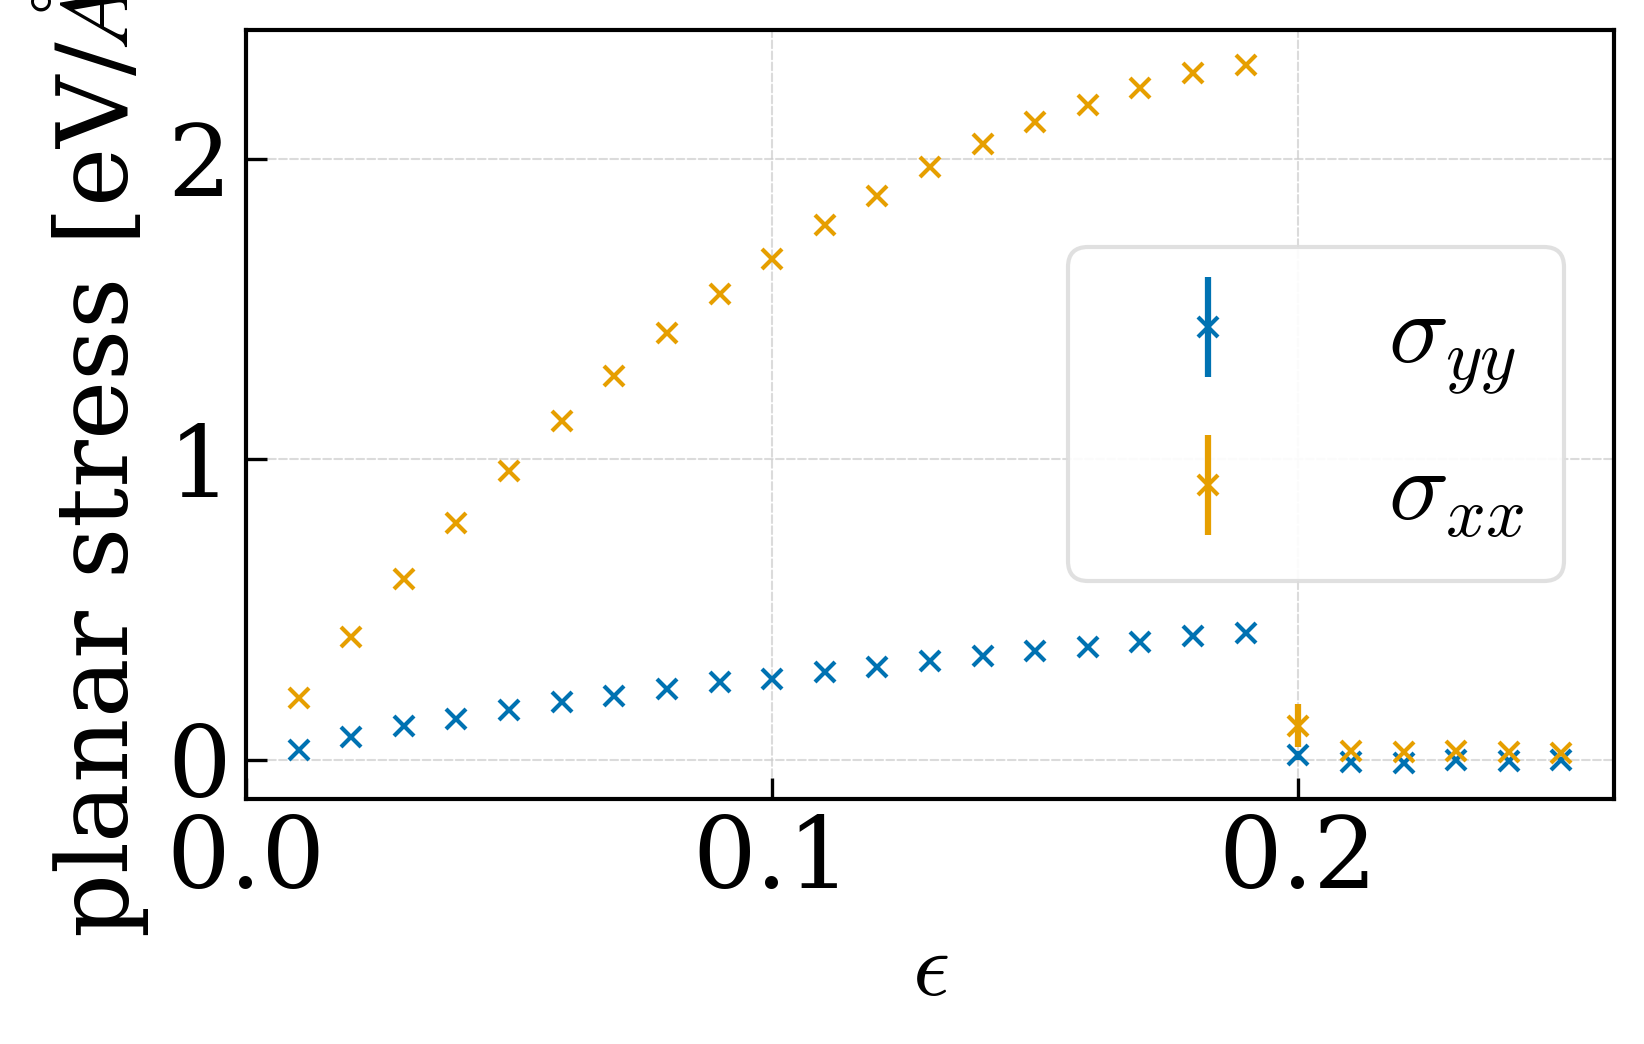

In [13]:
plt.errorbar(strains, stress_yy_means, yerr=stress_yy_stds, label=r"$\sigma_{yy}$", marker="x", linestyle="", markersize = 5)
plt.errorbar(strains, stress_xx_means, yerr=stress_xx_stds, label=r"$\sigma_{xx}$", marker="x", linestyle="", markersize = 5)

plt.legend()
plt.xlim((0, 0.26))
plt.grid(True)
plt.xlabel(r"$\epsilon$", fontsize = 22)
plt.ylabel(r"planar stress [eV/$\AA^2$]")
plt.tight_layout()
plt.savefig("MF_strain_stress.pdf")

## Check Temperature

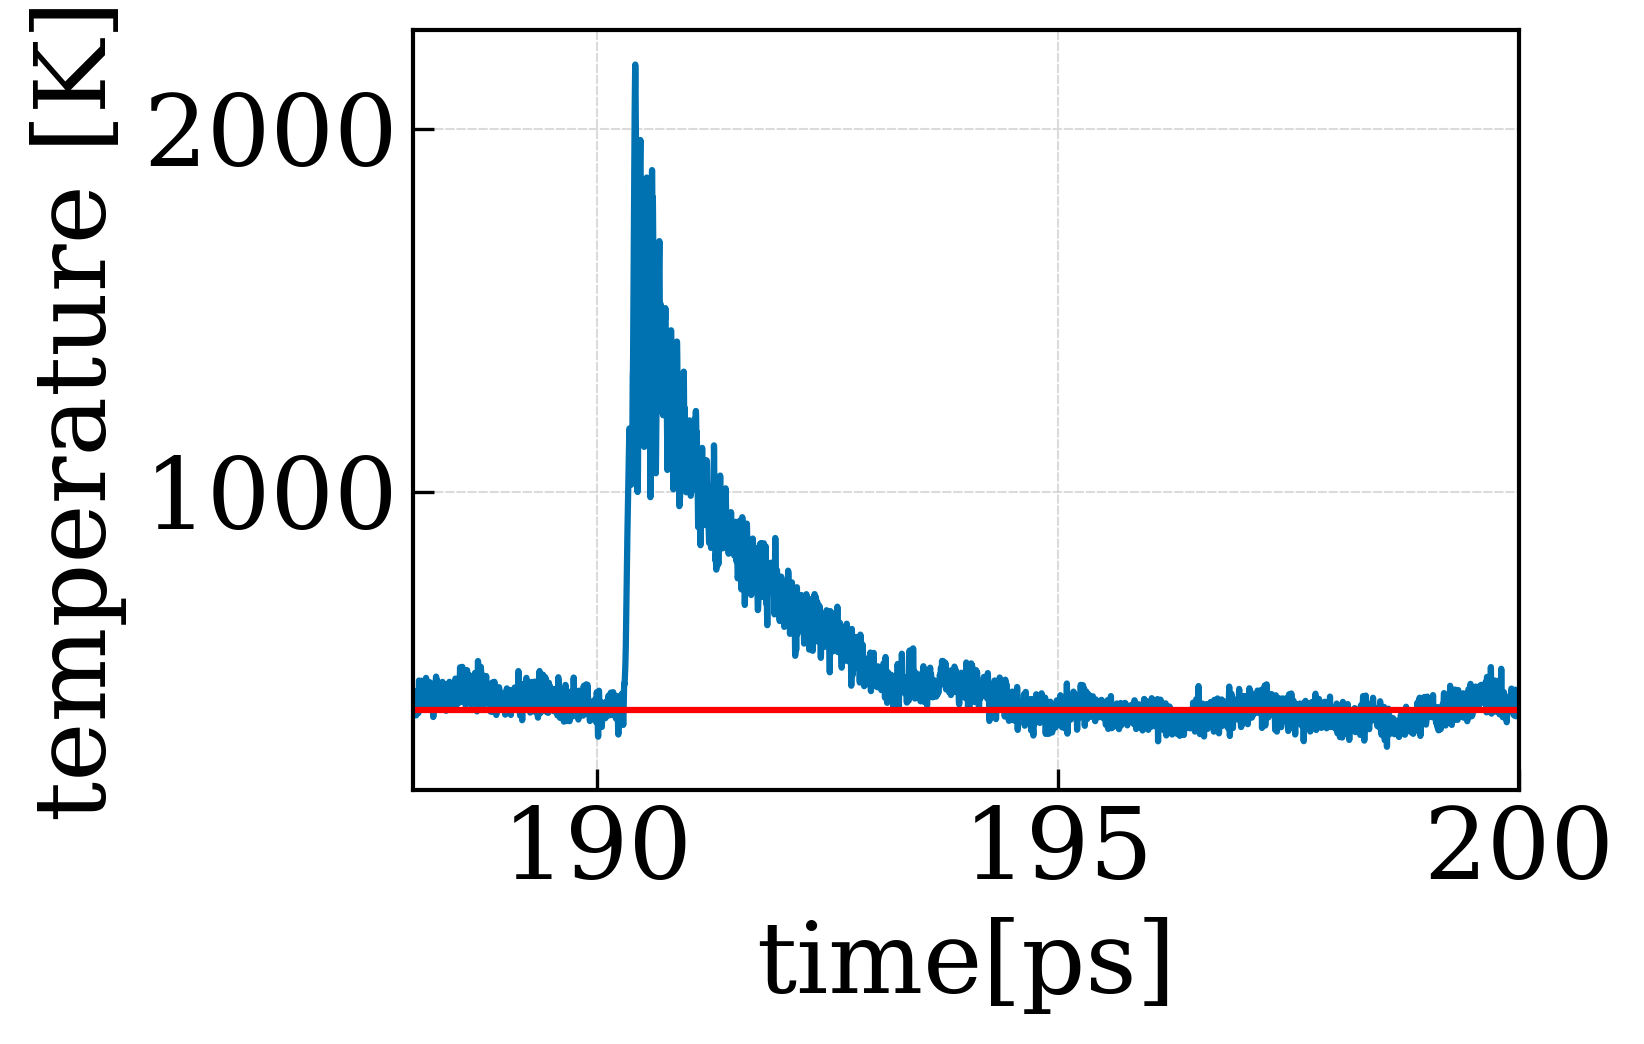

In [14]:
temps = thermo["Temp"]
plt.plot(thermo["Step"].values.astype(float)*0.001,temps)
plt.xlim(188,200)

plt.hlines(400, 185, 200, label = "400K", color = "red")

plt.xlabel("time[ps]")
plt.ylabel("temperature [K]")
plt.grid(True)
plt.tight_layout()
plt.savefig("MF_temperature.pdf")


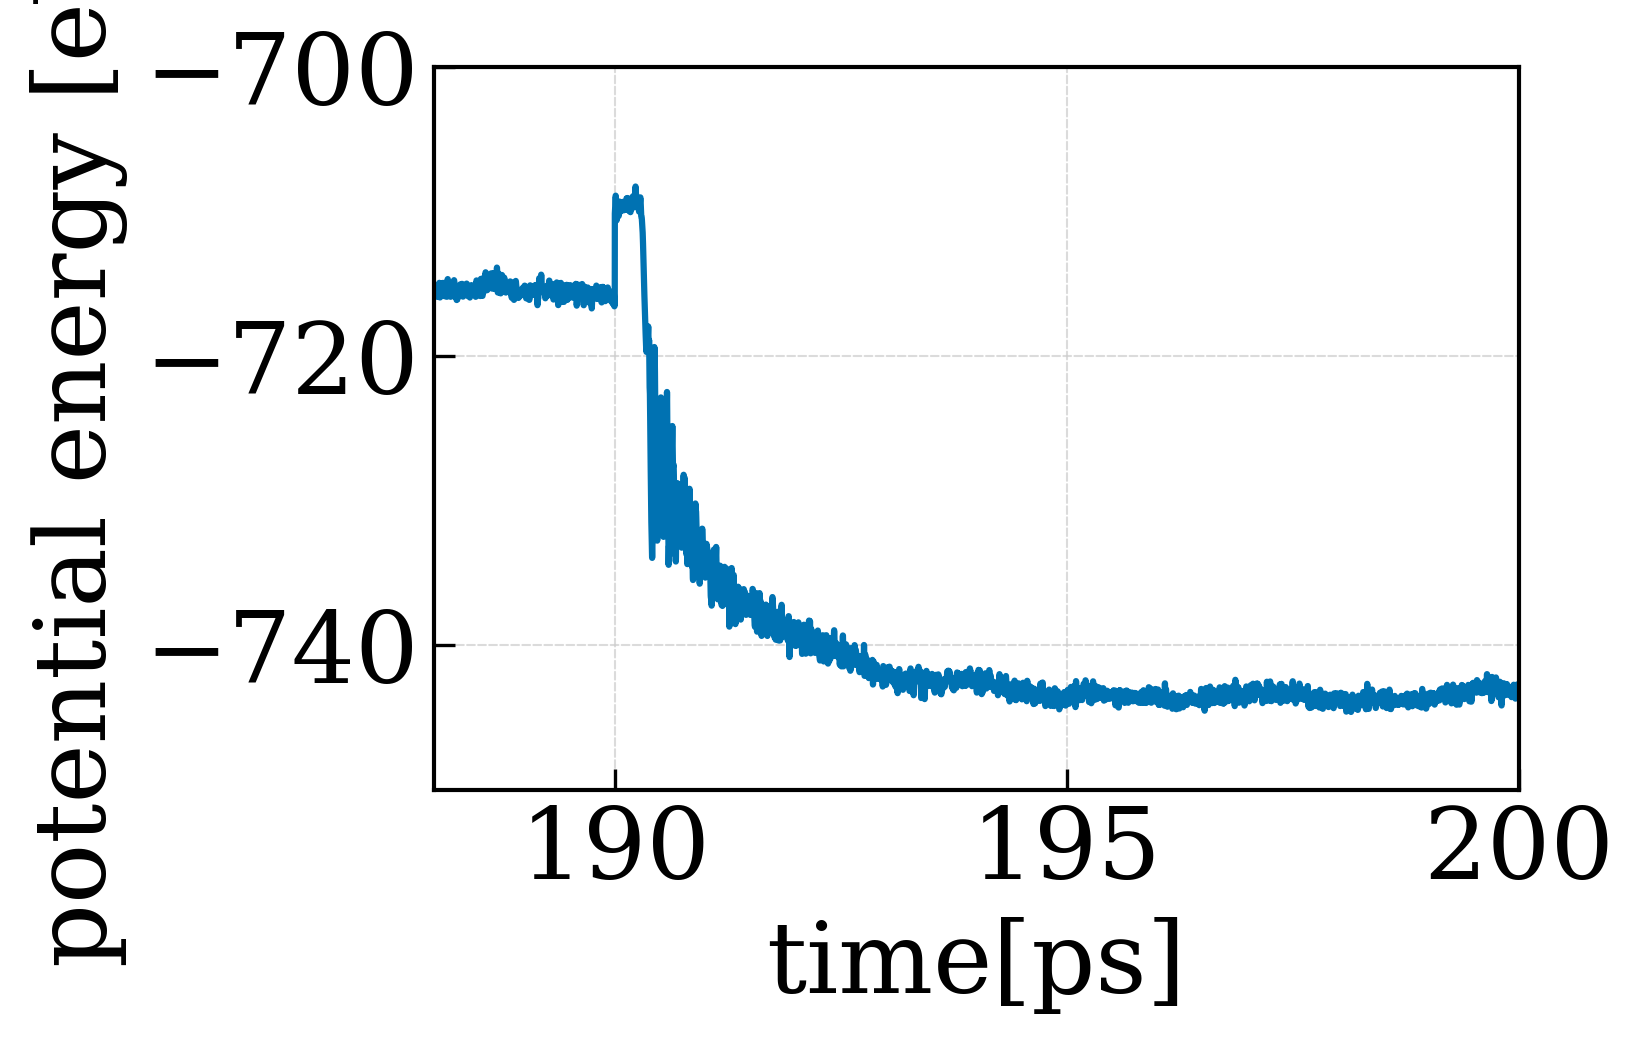

In [15]:
pes = thermo["PotEng"]
plt.plot(thermo["Step"].values.astype(float)*0.001,pes)
plt.xlim(188,200)
plt.ylim(-750, -700)

plt.xlabel("time[ps]")
plt.ylabel("potential energy [eV]")
plt.grid(True)
plt.tight_layout()
plt.savefig("MF_pes.pdf")


## Check correlation time

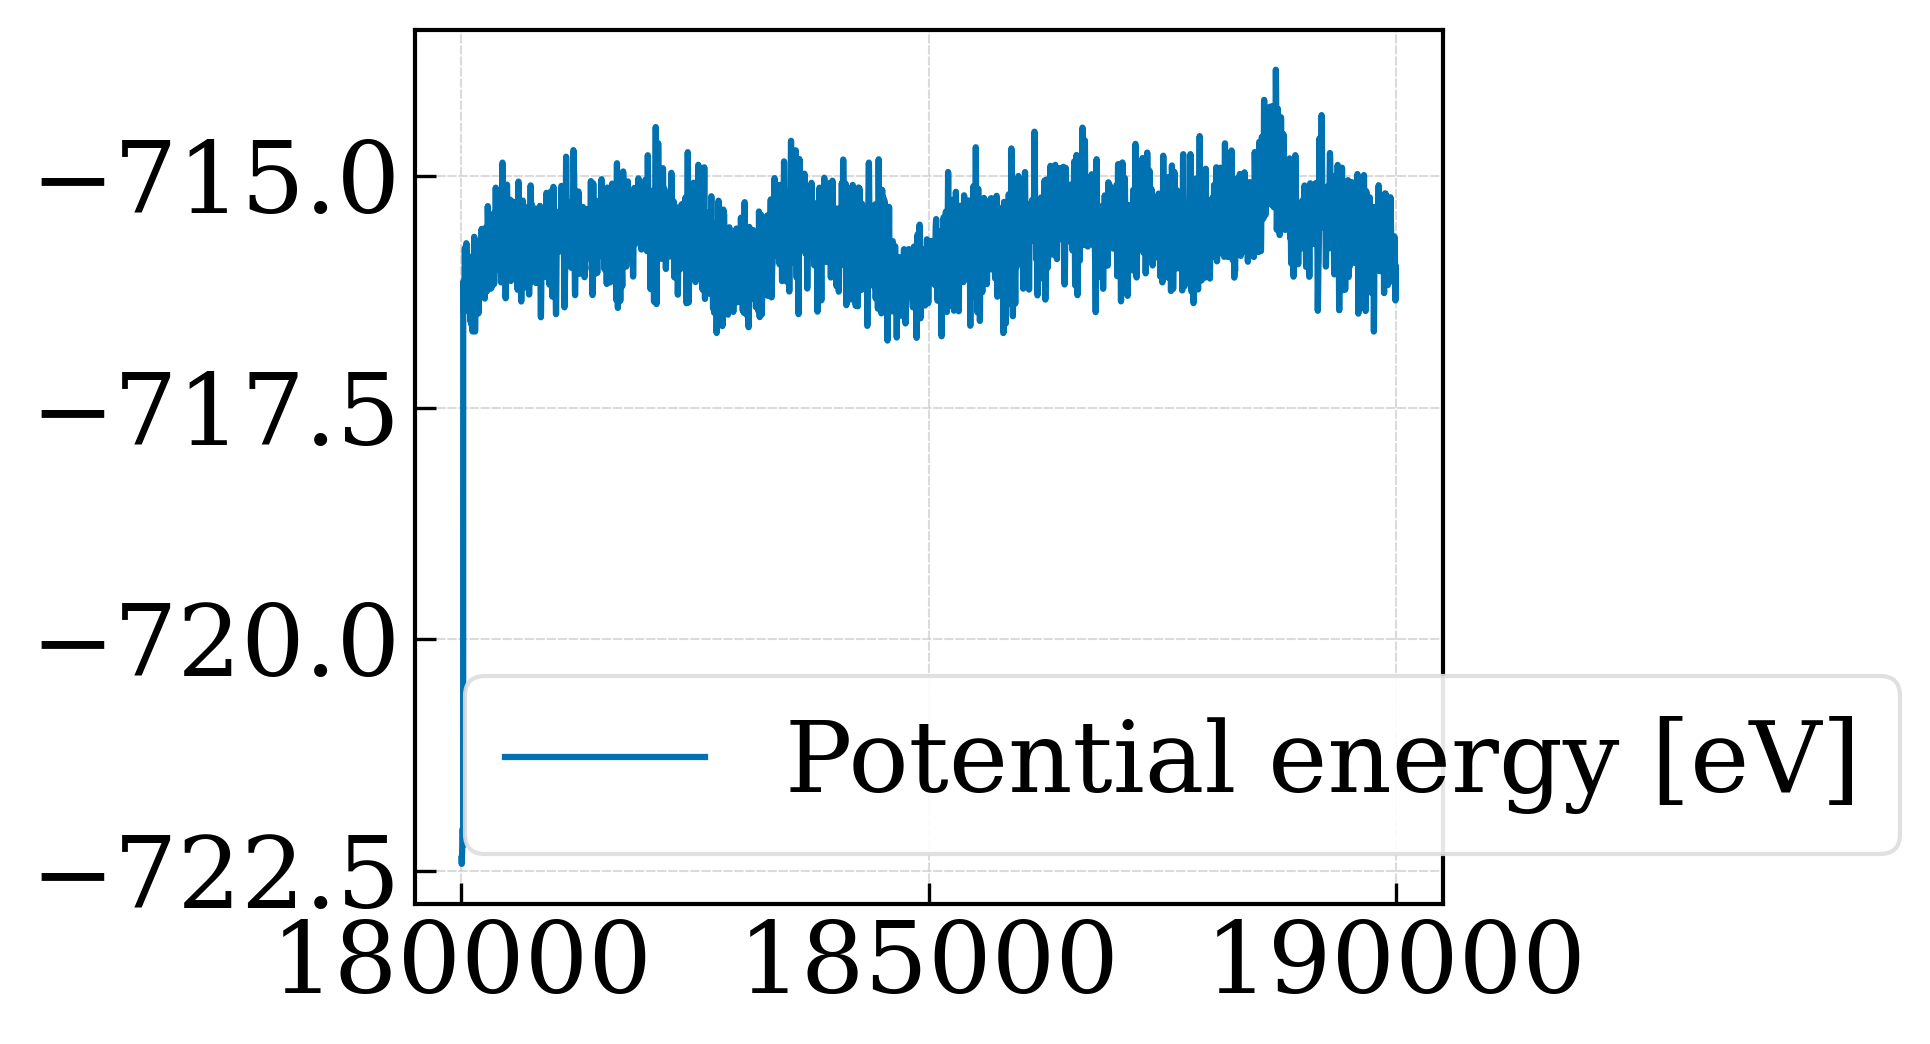

In [16]:
nsteps = 10000 # number of steps at each strain
slice_idx = 18 # select the slice
timestep = 1e-3 # in pseconds seconds
discard = 0 # discard first steps that are correlated with previous equilibrium

times = np.linspace(0, timestep*nsteps, num=nsteps)
data = thermo['PotEng'][slice_idx*nsteps:(slice_idx+1)*nsteps].astype(np.float64)
plt.plot(data, label = "Potential energy [eV]")
#plt.vlines(slice_idx*nsteps+discard, label = "discard", color = "red", ymin = np.min(data), ymax = np.max(data))

plt.legend()

data = data[discard:]
ndata = nsteps - discard
times = times[discard:]

Text(0, 0.5, 'pe PSD [eV/THz]')

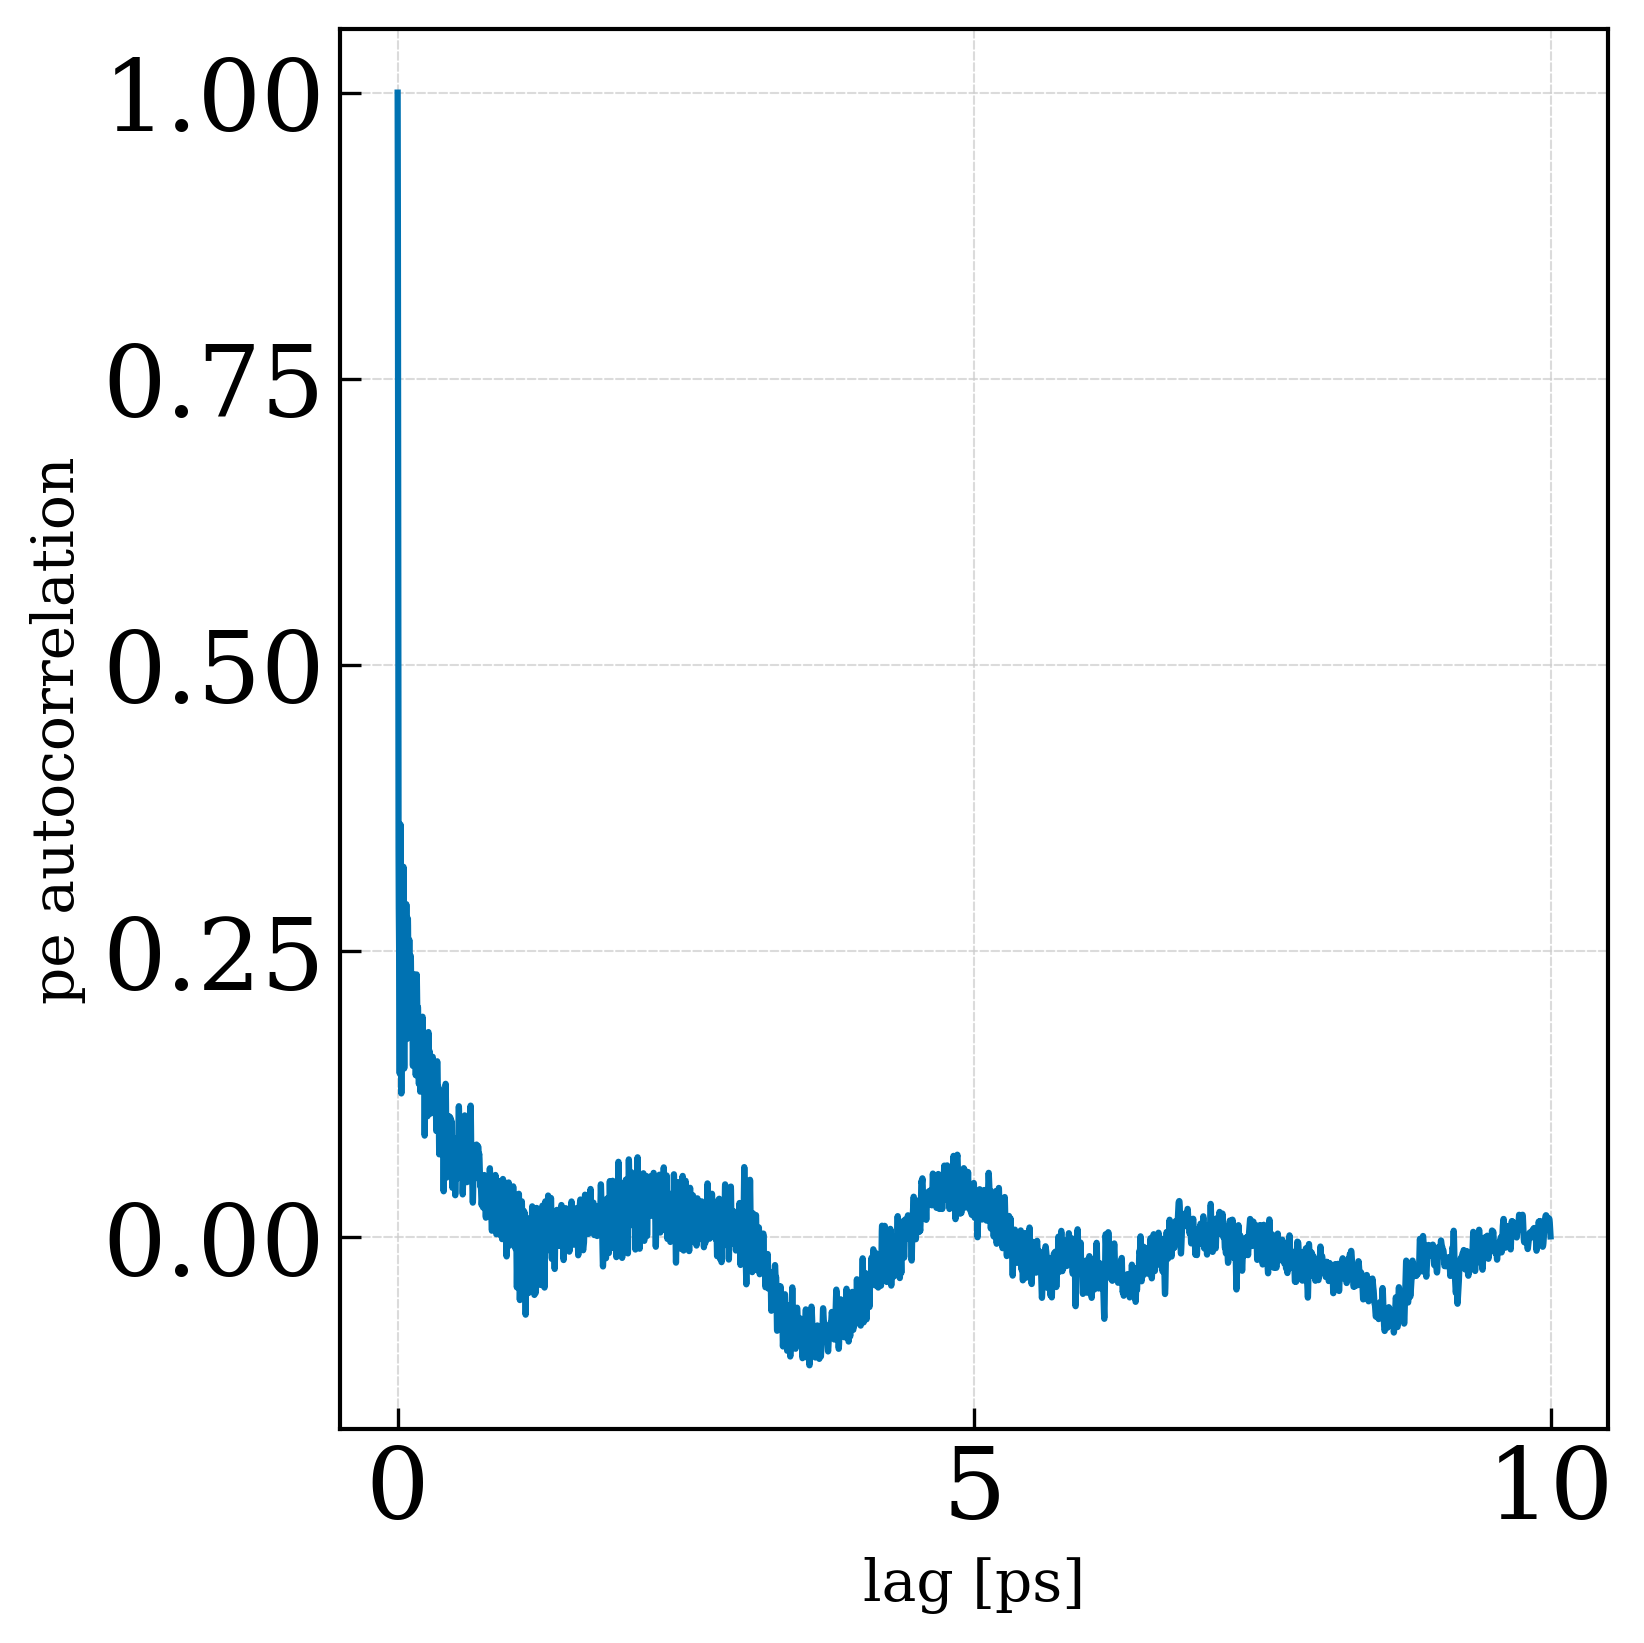

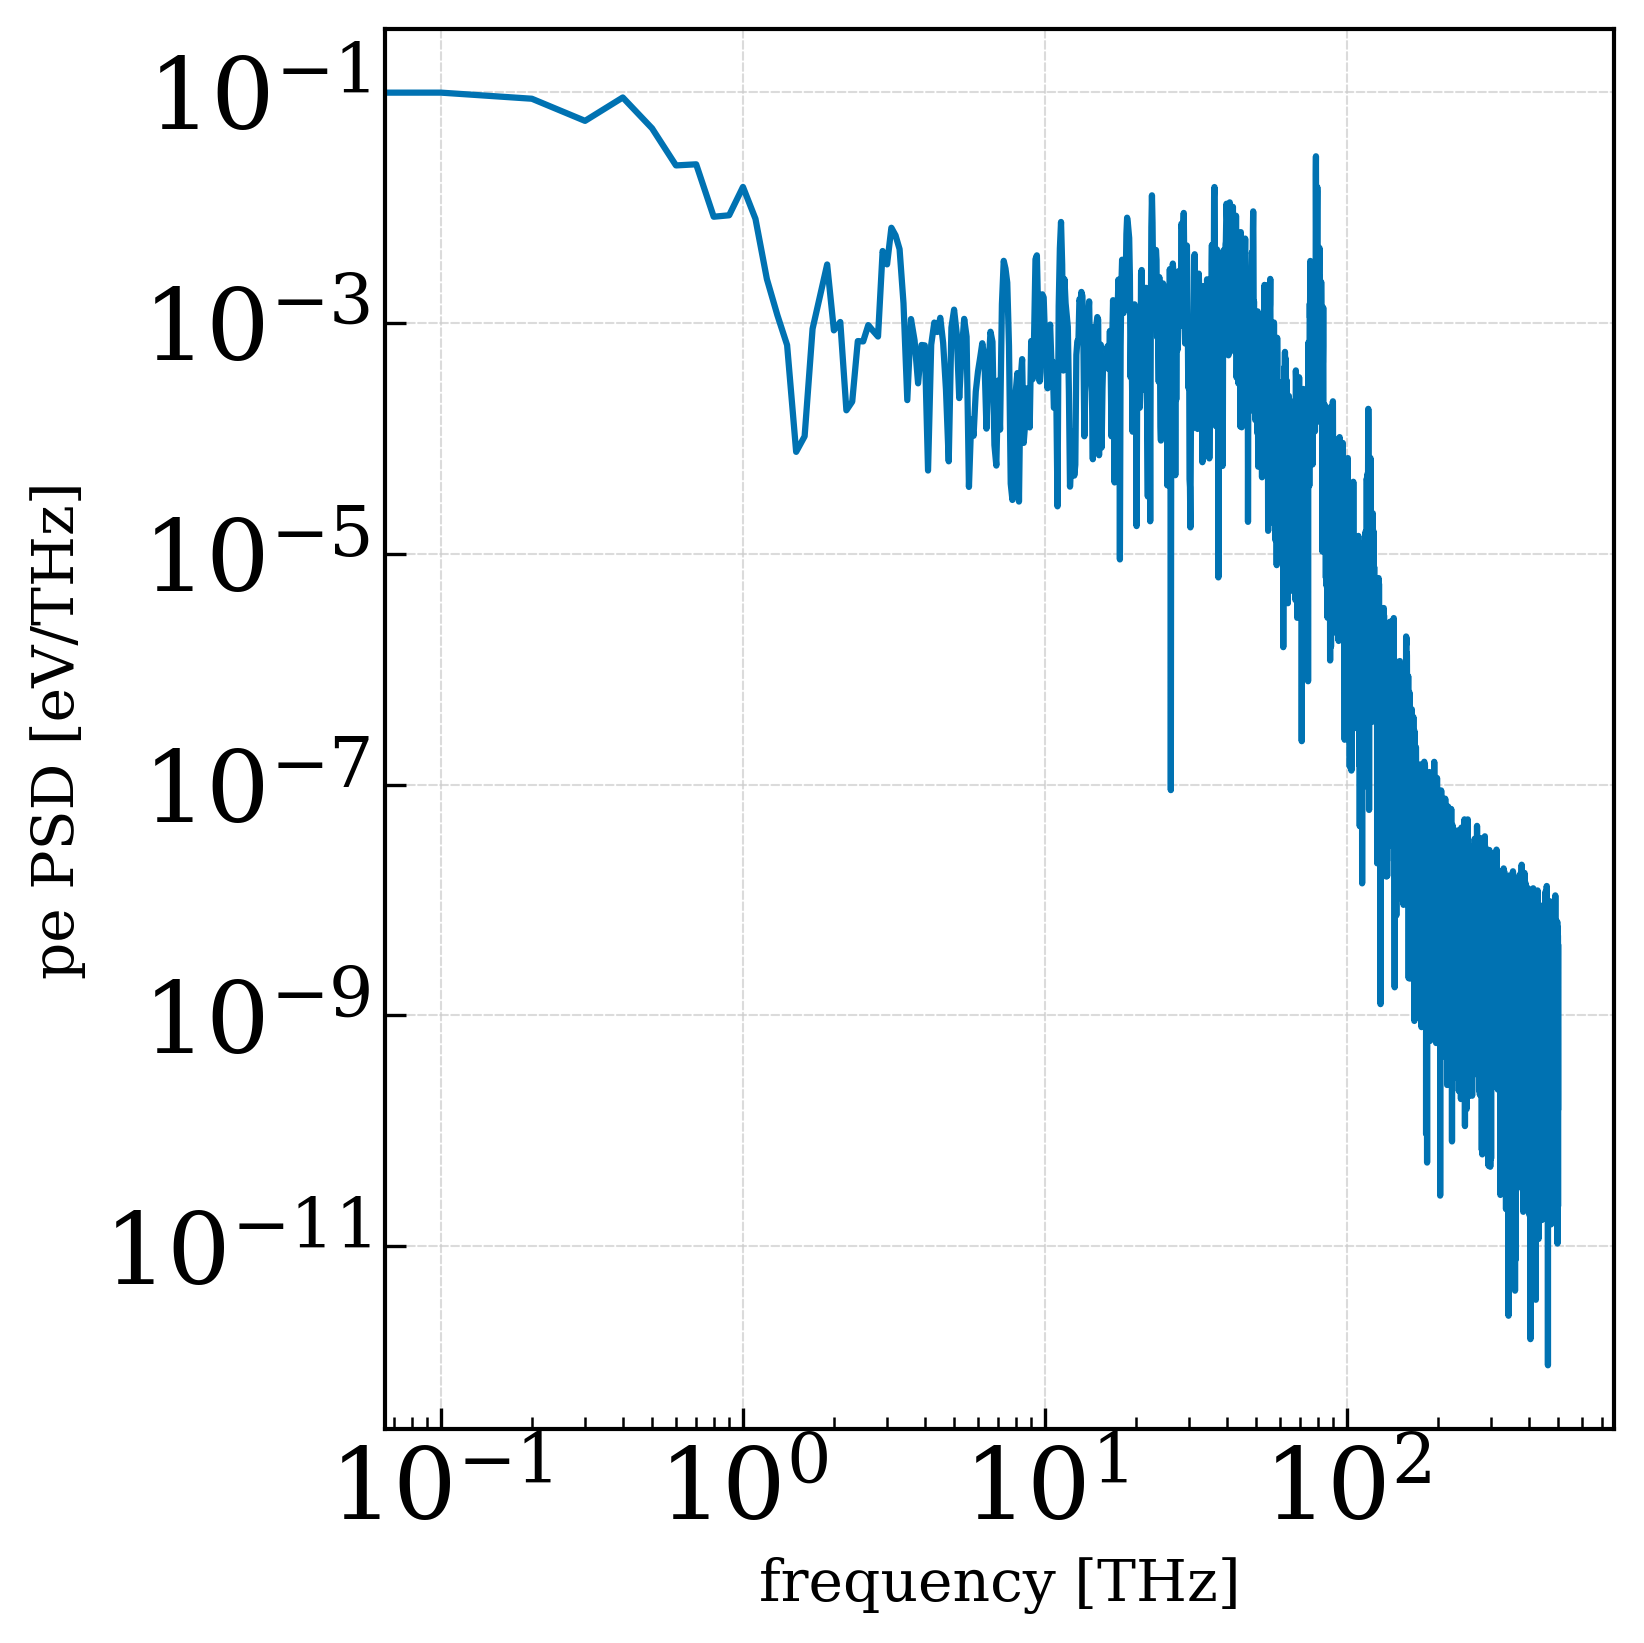

In [17]:
# remove the mean
unbiased_data = data - np.mean(data)
autocorrelation = correlate(unbiased_data, unbiased_data, "full")[ndata-1:]
autocorrelation /= autocorrelation[0]
sampling_freq = 1/timestep
fs, psd = periodogram(unbiased_data, sampling_freq, return_onesided=True, window='blackman')

axs = [None, None]

fix, axs[0] = plt.subplots(1,1, figsize = (6,6))

axs[0].plot(times - times[0], autocorrelation)
axs[0].set_xlabel("lag [ps]", fontsize = 14)
axs[0].set_ylabel(r"pe autocorrelation", fontsize = 14)


fix, axs[1] = plt.subplots(1,1, figsize = (6,6))

axs[1].plot(fs, psd)
axs[1].set_yscale("log")
axs[1].set_xscale("log")
axs[1].set_xlabel(r"frequency [THz]", fontsize=14)
axs[1].set_ylabel(r"pe PSD [eV/THz]", fontsize = 14)

10 -715.656968596 0.013398736686004652
100 -715.6569685959998 0.02777078434044412
125 -715.656968596 0.030753011276617004
250 -715.656968596 0.04019912119685032
500 -715.6569685960001 0.050313306359603044
1000 -715.6569685960001 0.06137976893640952
2500 -715.656968596 0.07555251910619833
5000 -715.6569685960001 0.11316809199996669


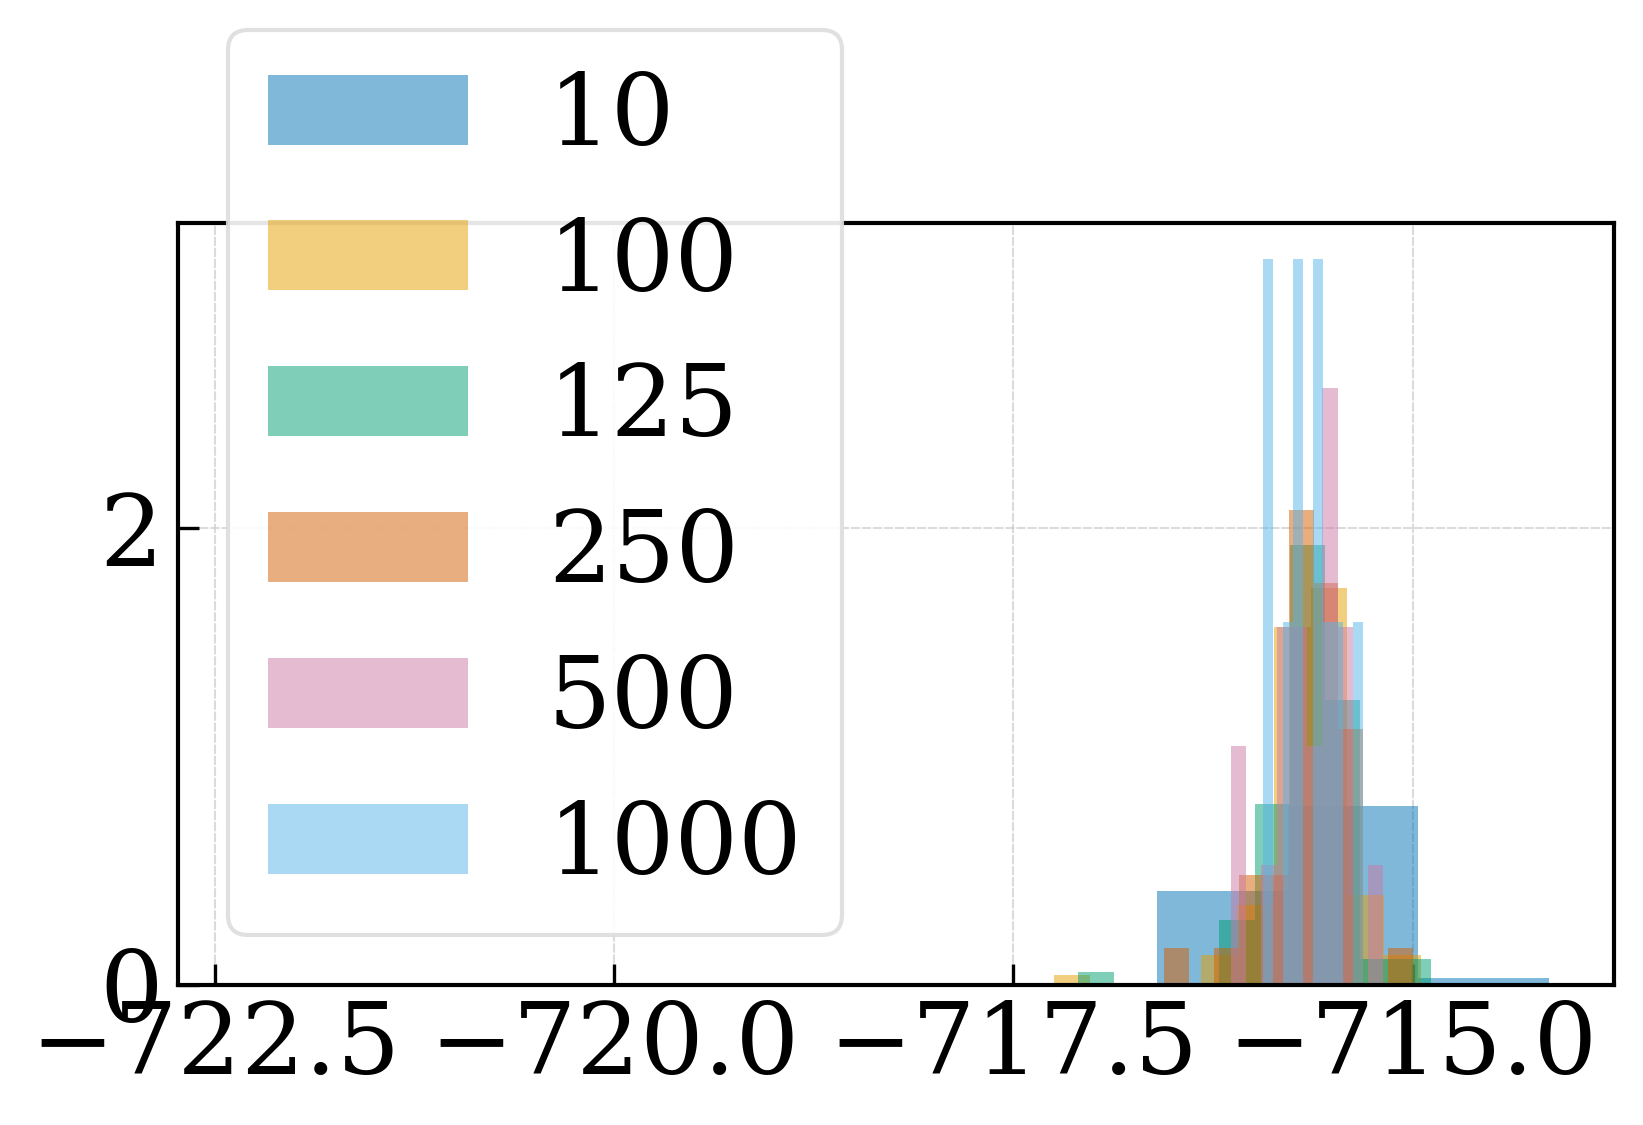

In [18]:
from data_blocking import *

block_sizes = [10,100,125,250,500,1000,2500, 5000]

mus = []
stds = []

for bs in block_sizes:
    means = compute_blocks(np.asarray(data), bs)
    mean, std = meanstd(means)
    print(bs, mean, std)
    if bs in [10,100,125,250,500,1000,1500, 2000, 3000]:
        plt.hist(means, label=bs, alpha=0.5, density=True)

    mus.append(mean)
    stds.append(std)

plt.legend()

Text(0, 0.5, 'mean uncertainty')

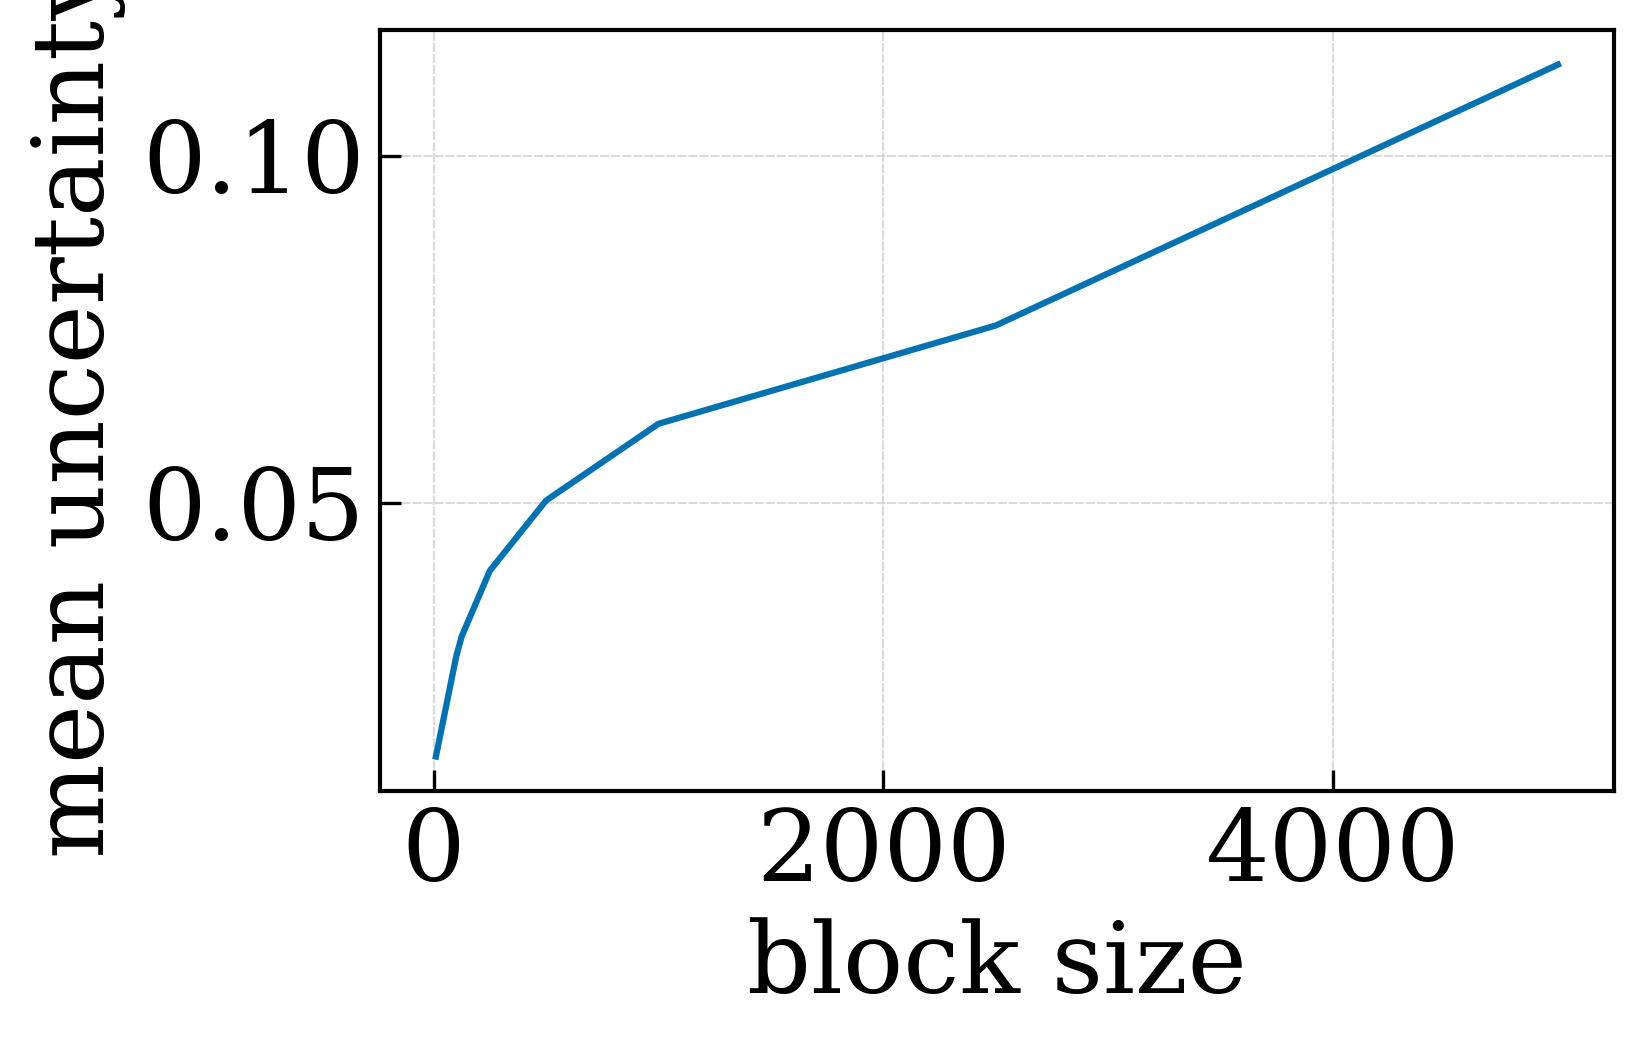

In [19]:
plt.plot(block_sizes, stds)
plt.xlabel("block size")
plt.ylabel("mean uncertainty")

In [20]:
strains, pes, pes_unc = data_blocking(thermo, "v_exx", "PotEng", 2000)

In [21]:
pes_unc

[np.float64(0.0740300388844203),
 np.float64(0.044792566067365314),
 np.float64(0.07364852698336258),
 np.float64(0.04801715284660592),
 np.float64(0.0655752323389287),
 np.float64(0.04990253965091714),
 np.float64(0.13226694043486648),
 np.float64(2.3296823640238693),
 np.float64(0.06275846276991792),
 np.float64(0.08232666996055021),
 np.float64(0.05059527203040192),
 np.float64(0.09089424503735836),
 np.float64(0.06678898809306456),
 np.float64(0.12094751969296573),
 np.float64(0.07332697004318837),
 np.float64(0.1132204808682932),
 np.float64(0.05722906947546907),
 np.float64(0.08687350121044746),
 np.float64(0.09671687460195572),
 np.float64(0.06572171930958899),
 np.float64(0.0701061278580948),
 np.float64(0.08143210179737684),
 np.float64(0.07877235813867367),
 np.float64(0.09041140870931817),
 np.float64(0.07709427552117419)]

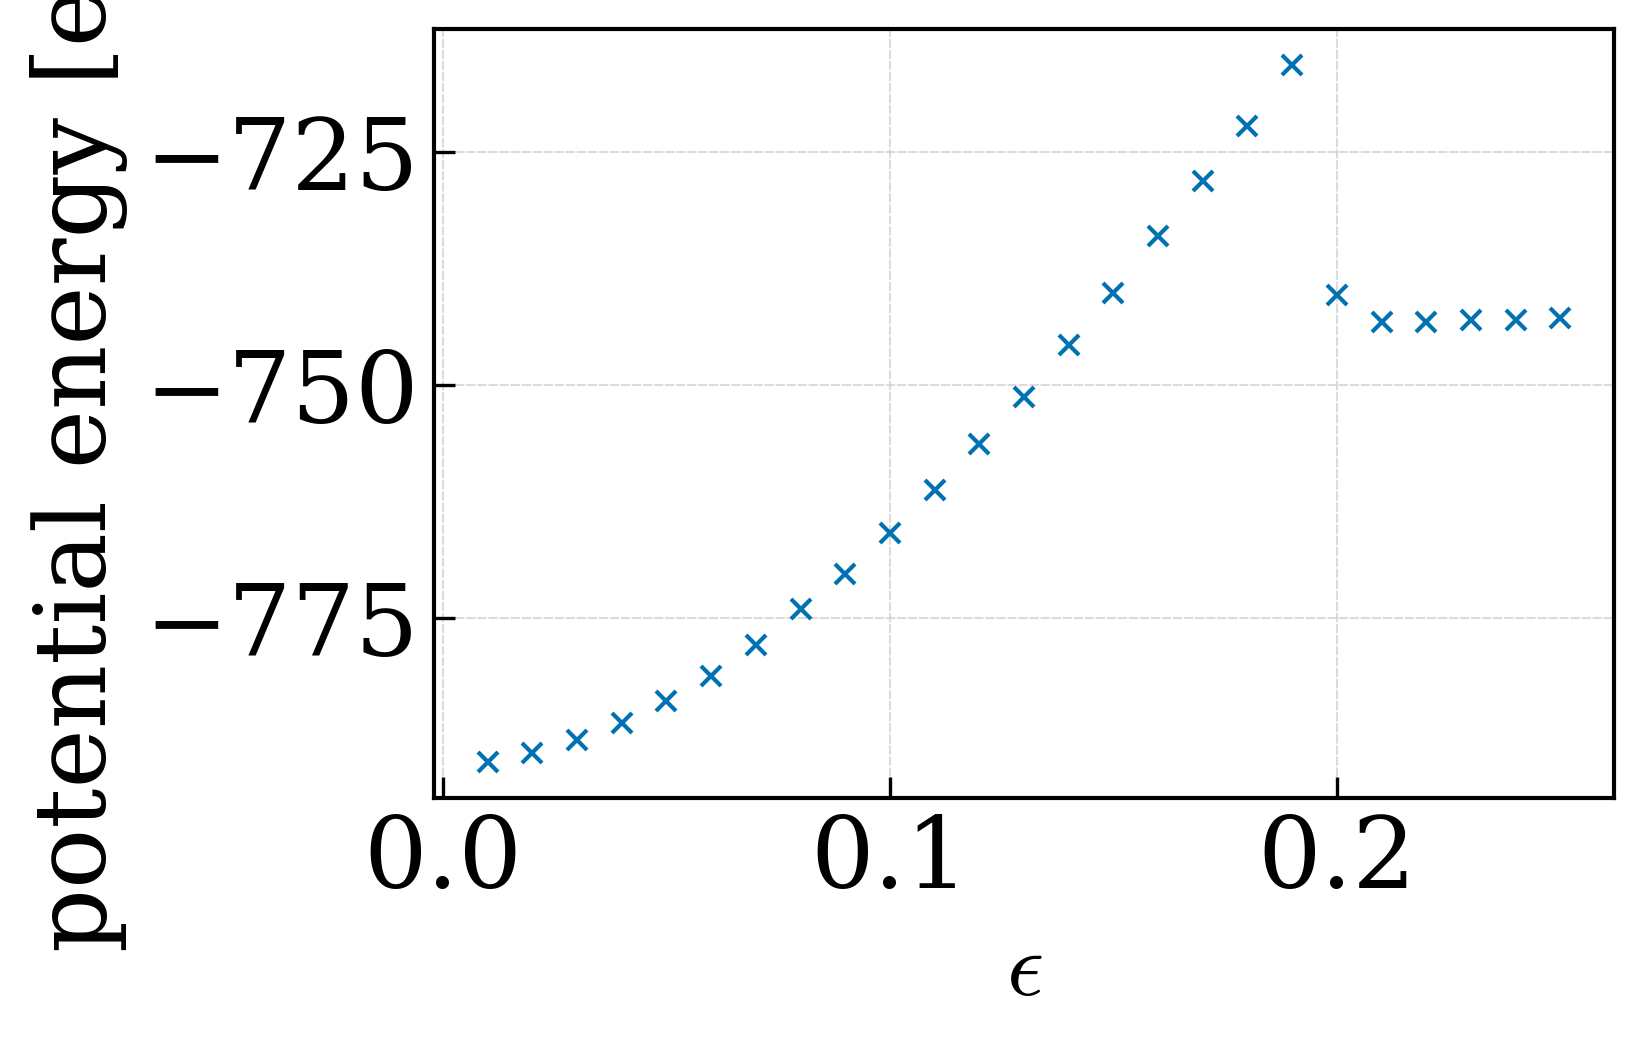

In [22]:
plt.errorbar(strains, pes, yerr = pes_unc, marker = "x", linewidth=0, markersize = 5)
plt.xlabel(r"$\epsilon$", fontsize = 22)
plt.ylabel("potential energy [eV]")
plt.grid(True)
plt.tight_layout()
plt.savefig("MF_pes_average.pdf")

In [23]:
strains, tote, tote_unc = data_blocking(thermo, "v_exx", "TotEng", 2000)

<ErrorbarContainer object of 3 artists>

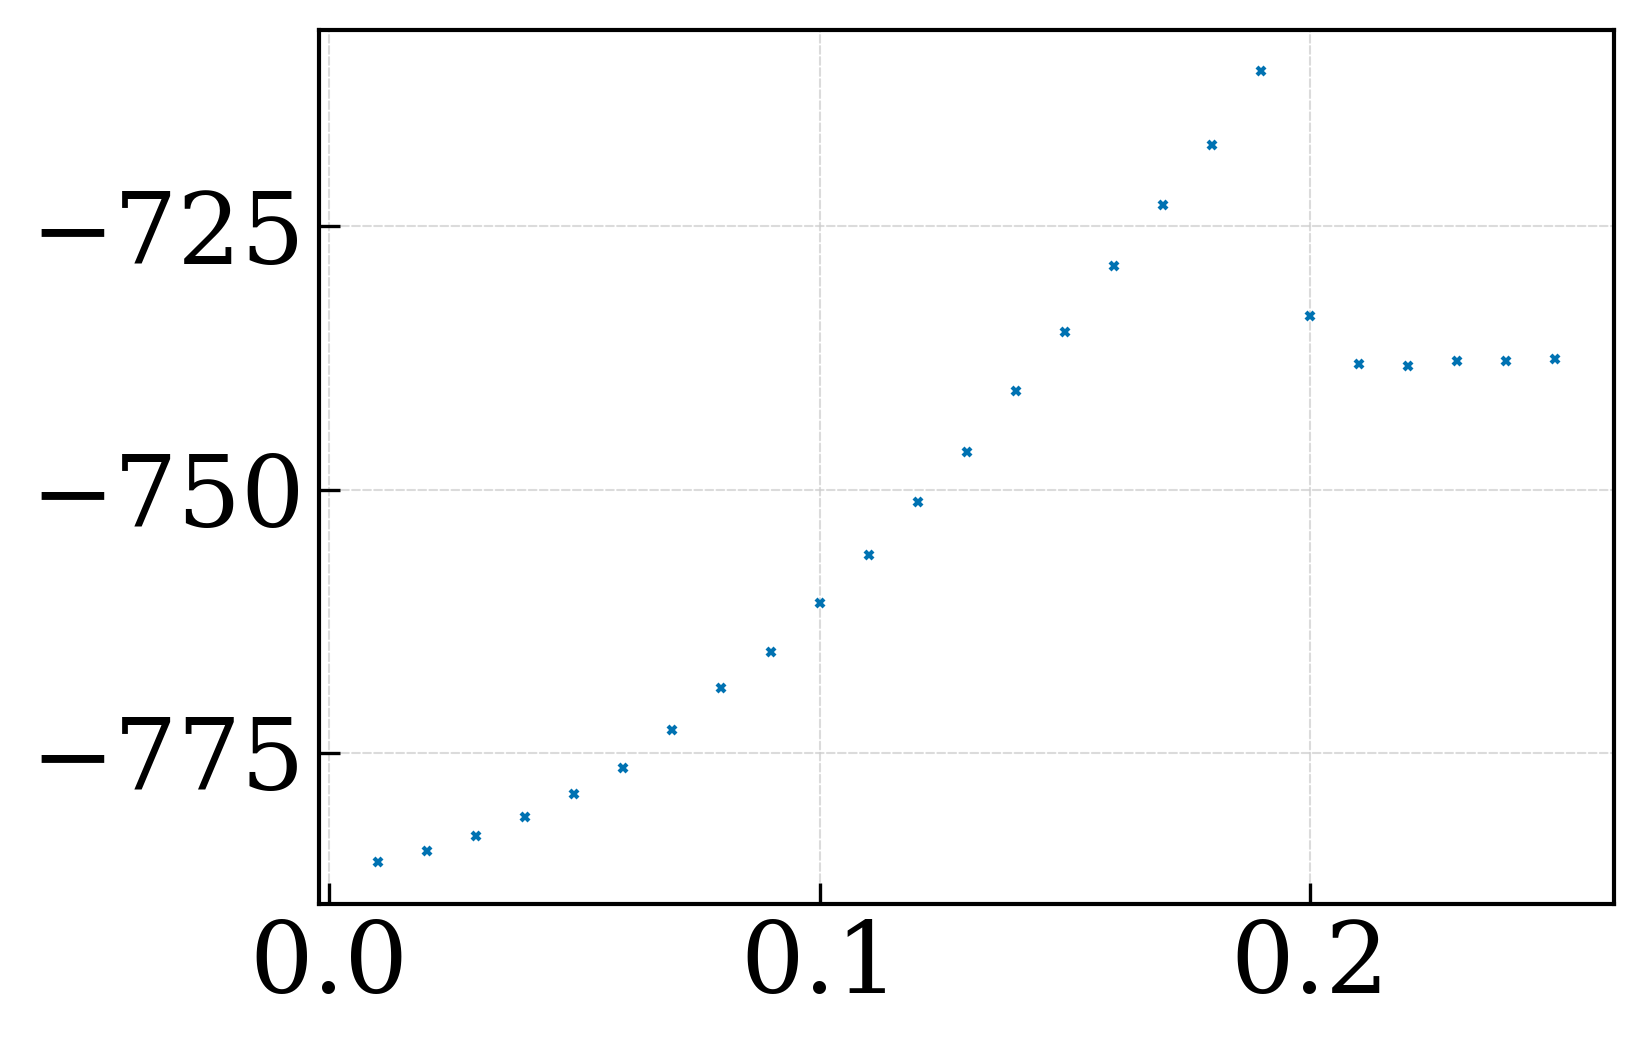

In [24]:
plt.errorbar(strains, tote, yerr = tote_unc, marker = "x", linewidth=0)

In [25]:
strains, kine, kine_unc = data_blocking(thermo, "v_exx", "KinEng", 1000)

<ErrorbarContainer object of 3 artists>

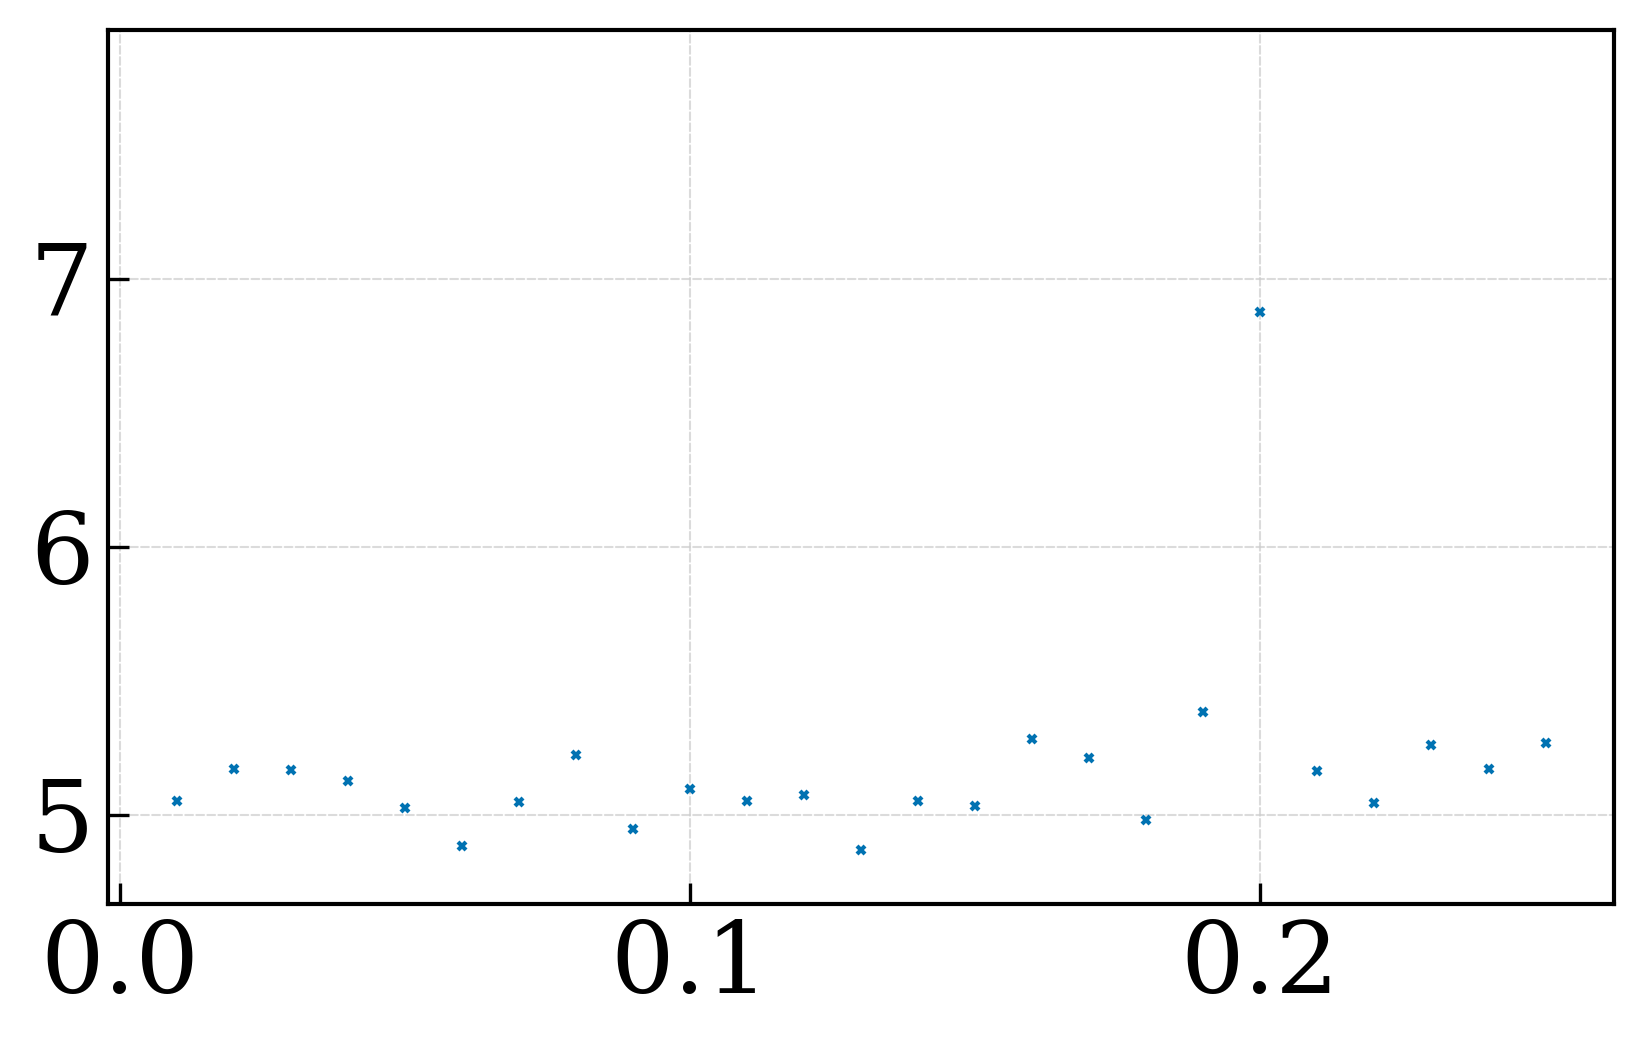

In [26]:
plt.errorbar(strains, kine, yerr = kine_unc, marker = "x", linewidth=0)

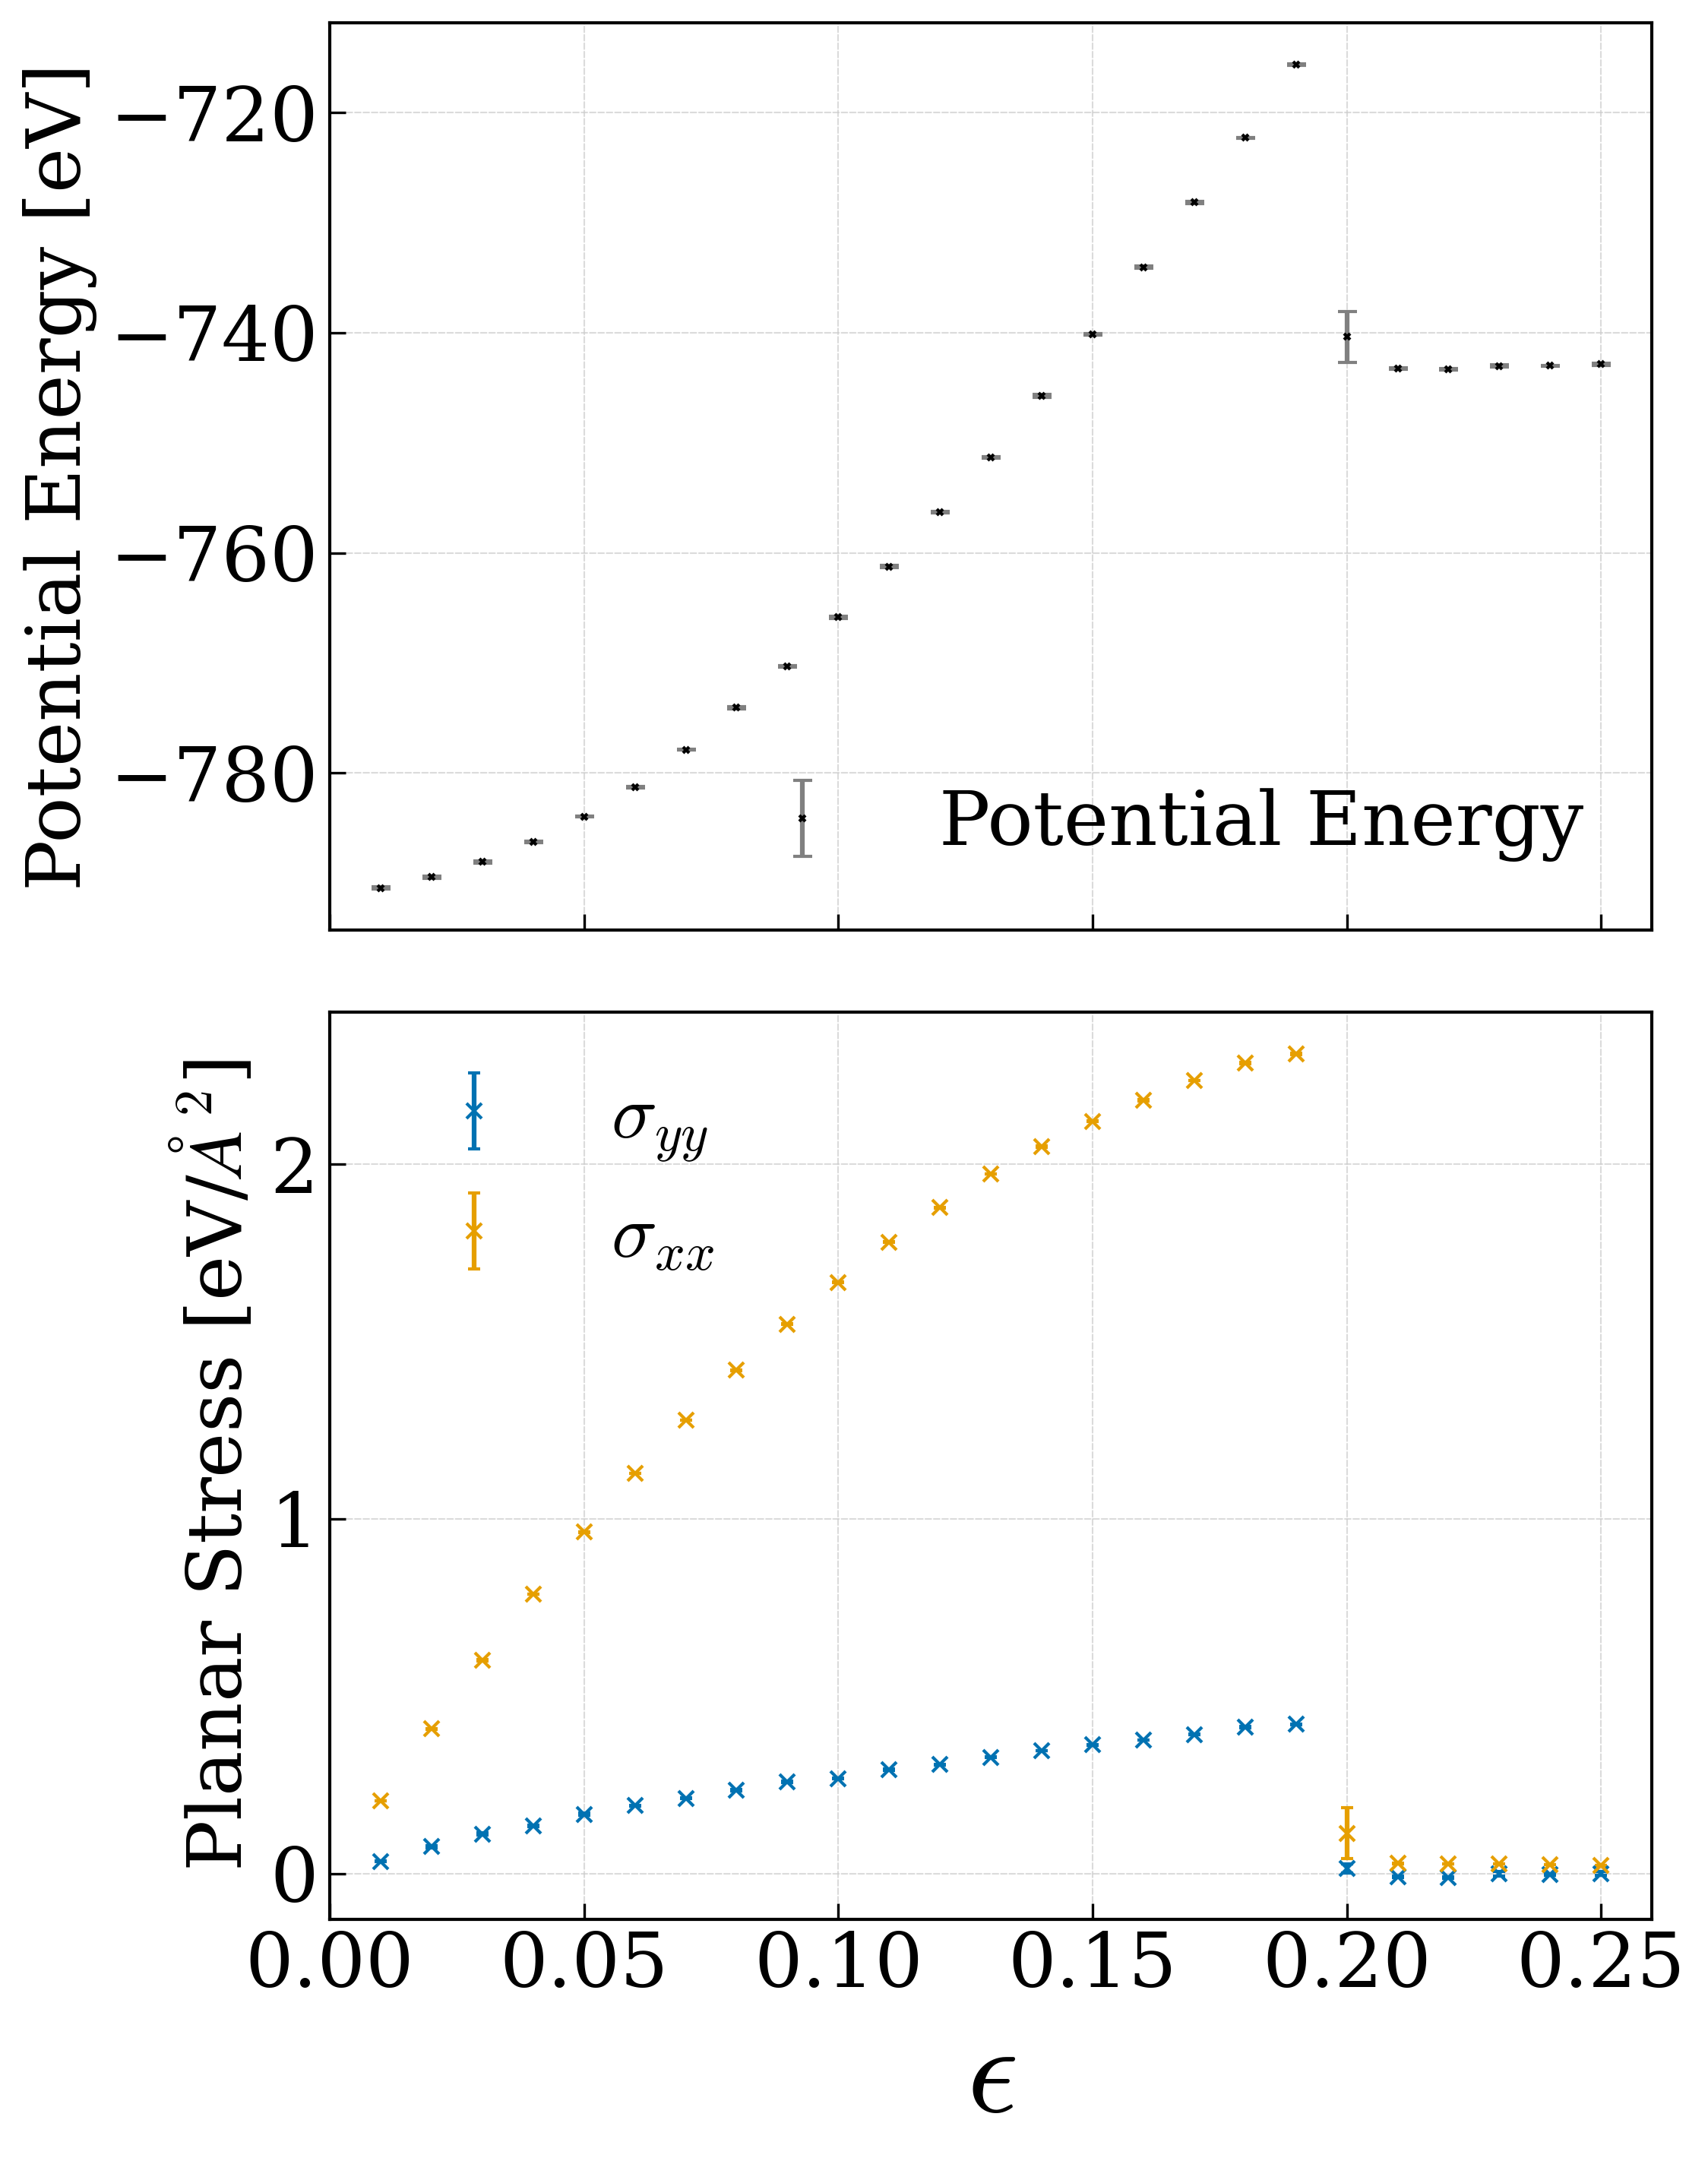

In [30]:
import matplotlib.pyplot as plt

# Using sharex=True to link axes and automatically manage labels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ticks = np.linspace(0, 0.25, 6)
labels = [f"{t:.2f}" for t in ticks]

# Plot 1: Total Energy
ax1.errorbar(strains, pes, yerr=pes_unc, marker="x", linestyle="", 
             color="black", ecolor="gray", capsize=3, label="Potential Energy")
ax1.set_ylabel(r"Potential Energy [eV]")
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(frameon=False)

# Plot 2: Planar Stress
ax2.errorbar(strains, stress_yy_means, yerr=stress_yy_stds, label=r"$\sigma_{yy}$", 
             marker="x", linestyle="", markersize=5, capsize=2)
ax2.errorbar(strains, stress_xx_means, yerr=stress_xx_stds, label=r"$\sigma_{xx}$", 
             marker="x", linestyle="", markersize=5, capsize=2)

ax2.set_xlabel(r"$\epsilon$", fontsize = 40)
ax2.set_ylabel(r"Planar Stress [eV/$\AA^2$]")
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(frameon=False)

# Set limits
ax2.set_xlim(0, 0.26)
ax2.set_xticks(ticks)
ax2.set_xticklabels(labels)

plt.tight_layout()
plt.savefig("thermoquantities.svg", transparent = True)